<a href="https://colab.research.google.com/github/shoxruxmamitov/kichik-loiha/blob/main/kredit_berish_holatlarini_bashorat_qilish.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn import svm
from sklearn.metrics import accuracy_score

In [ ]:
loan_dataset = pd.read_csv('/content/archive.zip')

In [ ]:
type(loan_dataset)

pandas.core.frame.DataFrame

In [ ]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,LP001002,Male,No,0,Graduate,No,5849,0.0,NaN,360.0,1.0,Urban,Y
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,N
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,Y
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,Y
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,Y


In [ ]:
loan_dataset.shape

(614, 13)

In [ ]:
loan_dataset.size

7982

In [ ]:
loan_dataset.describe()

,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History
count,614.000000,614.000000,592.000000,600.00000,564.000000
mean,5403.459283,1621.245798,146.412162,342.00000,0.842199
std,6109.041673,2926.248369,85.587325,65.12041,0.364878
min,150.000000,0.000000,9.000000,12.00000,0.000000
25%,2877.500000,0.000000,100.000000,360.00000,1.000000
50%,3812.500000,1188.500000,128.000000,360.00000,1.000000
75%,5795.000000,2297.250000,168.000000,360.00000,1.000000
max,81000.000000,41667.000000,700.000000,480.00000,1.000000


In [ ]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,13
Married,3
Dependents,15
Education,0
Self_Employed,32
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,22
Loan_Amount_Term,14


In [ ]:
loan_dataset = loan_dataset.dropna()

In [ ]:
loan_dataset.isnull().sum()

,0
Loan_ID,0
Gender,0
Married,0
Dependents,0
Education,0
Self_Employed,0
ApplicantIncome,0
CoapplicantIncome,0
LoanAmount,0
Loan_Amount_Term,0


In [ ]:
loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)
#loan_statusni qimatini son koirinishiga otkizib oldik

/tmp/ipykernel_12650/3924500861.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_dataset.replace({"Loan_Status":{'N':0,'Y':1}},inplace=True)


In [ ]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,Male,Yes,1,Graduate,No,4583,1508.0,128.0,360.0,1.0,Rural,0
2,LP001005,Male,Yes,0,Graduate,Yes,3000,0.0,66.0,360.0,1.0,Urban,1
3,LP001006,Male,Yes,0,Not Graduate,No,2583,2358.0,120.0,360.0,1.0,Urban,1
4,LP001008,Male,No,0,Graduate,No,6000,0.0,141.0,360.0,1.0,Urban,1
5,LP001011,Male,Yes,2,Graduate,Yes,5417,4196.0,267.0,360.0,1.0,Urban,1


In [ ]:
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
3+,41


In [ ]:
loan_dataset.replace({'3+':4},inplace=True)

/tmp/ipykernel_12650/1650618922.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_dataset.replace({'3+':4},inplace=True)


In [ ]:
loan_dataset['Dependents'].value_counts()

,count
Dependents,
0,274
2,85
1,80
4,41


viziualizatsia

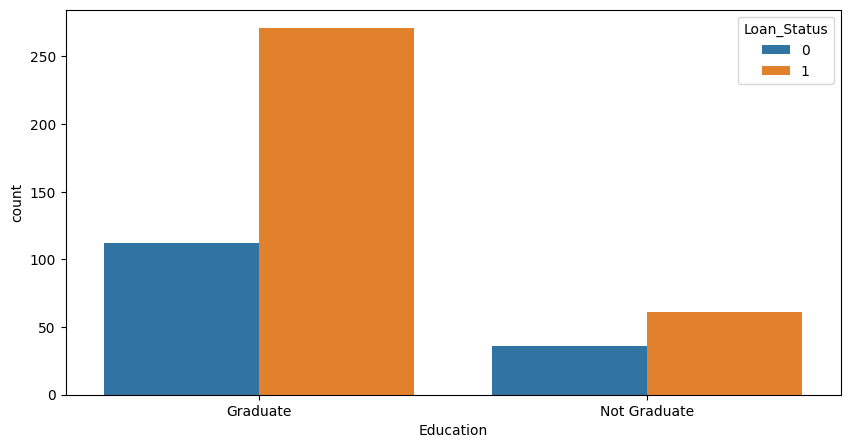

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Education',hue='Loan_Status',data=loan_dataset)
plt.show()

/tmp/ipykernel_12650/2338177545.py:2: FutureWarning: 

Setting a gradient palette using color= is deprecated and will be removed in v0.14.0. Set `palette='dark:r'` for the same effect.

  sns.countplot(x='Married',hue='Loan_Status',data=loan_dataset, color='r')


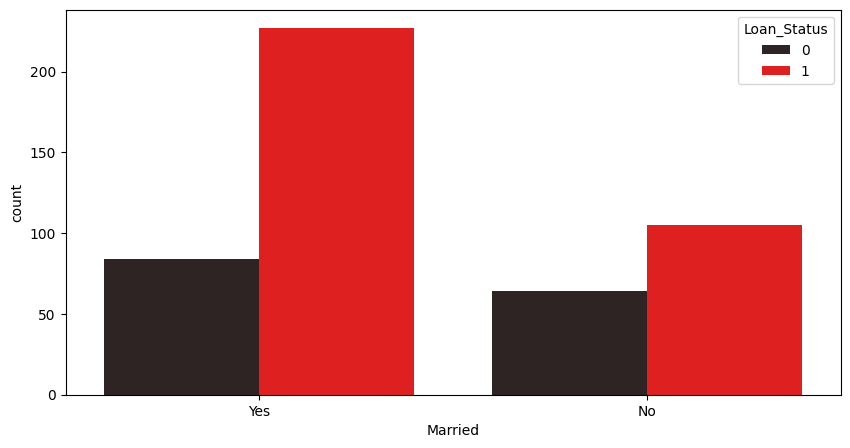

In [ ]:
plt.figure(figsize=(10,5))
sns.countplot(x='Married',hue='Loan_Status',data=loan_dataset, color='r')
plt.show()

In [42]:
loan_dataset.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0}}, inplace=True)
# married ustuni qimatini 0 va 1 songa Gender teng ustun qimatini esa 1 va 0 songa  va boshqa ustunlarni ham ozgartriiib oldik

/tmp/ipykernel_12650/652234412.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_dataset.replace({'Married':{'No':0,'Yes':1},'Gender':{'Male':1,'Female':0}}, inplace=True)


In [ ]:
loan_dataset.sample(10)

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
269,LP001884,0,0,1,Graduate,No,2876,1560.0,90.0,360.0,1.0,Urban,1
401,LP002296,1,0,0,Not Graduate,No,2755,0.0,65.0,300.0,1.0,Rural,0
403,LP002300,0,0,0,Not Graduate,No,1963,0.0,53.0,360.0,1.0,Semiurban,1
465,LP002494,1,0,0,Graduate,No,6000,0.0,140.0,360.0,1.0,Rural,1
14,LP001030,1,1,2,Graduate,No,1299,1086.0,17.0,120.0,1.0,Urban,1
212,LP001713,1,1,1,Graduate,Yes,7787,0.0,240.0,360.0,1.0,Urban,1
562,LP002820,1,1,0,Graduate,No,5923,2054.0,211.0,360.0,1.0,Rural,1
278,LP001907,1,1,0,Graduate,No,14583,0.0,436.0,360.0,1.0,Semiurban,1
182,LP001636,1,1,0,Graduate,No,4600,0.0,73.0,180.0,1.0,Semiurban,1
613,LP002990,0,0,0,Graduate,Yes,4583,0.0,133.0,360.0,0.0,Semiurban,0


In [43]:
loan_dataset.replace({
    'Self_Employed': {'No': 1, 'Yes': 1},
    'Property_Area': {'Rural': 0, 'Semiurban': 1, 'Urban': 2},
    'Education': {'Graduate': 0, 'Not Graduate': 1}
}, inplace=True)
# married ustuni qimatini 0 va 1 songa Gender teng ustun qimatini esa 1 va 0 songa  va boshqa ustunlarni ham ozgartriiib oldik

/tmp/ipykernel_12650/4148066387.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  loan_dataset.replace({


In [ ]:
loan_dataset.head()

,Loan_ID,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
1,LP001003,1,1,1,0,1,4583,1508.0,128.0,360.0,1.0,0,0
2,LP001005,1,1,0,0,1,3000,0.0,66.0,360.0,1.0,2,1
3,LP001006,1,1,0,1,1,2583,2358.0,120.0,360.0,1.0,2,1
4,LP001008,1,0,0,0,1,6000,0.0,141.0,360.0,1.0,2,1
5,LP001011,1,1,2,0,1,5417,4196.0,267.0,360.0,1.0,2,1


In [ ]:
X = loan_dataset.drop(columns=['Loan_ID','Loan_Status'],axis=1)
Y = loan_dataset['Loan_Status']

In [ ]:
print(X)
print(Y)

     Gender  Married  ... Credit_History  Property_Area
1         1        1  ...            1.0              0
2         1        1  ...            1.0              2
3         1        1  ...            1.0              2
4         1        0  ...            1.0              2
5         1        1  ...            1.0              2
..      ...      ...  ...            ...            ...
609       0        0  ...            1.0              0
610       1        1  ...            1.0              0
611       1        1  ...            1.0              2
612       1        1  ...            1.0              2
613       0        0  ...            0.0              1

[480 rows x 11 columns]
1      0
2      1
3      1
4      1
5      1
      ..
609    1
610    1
611    1
612    1
613    0
Name: Loan_Status, Length: 480, dtype: int64


In [ ]:
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.1, stratify=Y, random_state=2)
#

support vector machine learning

In [45]:
classifier = svm.SVC(kernel='linear')

In [46]:
classifier.fit(X_train,Y_train)

SVC(kernel='linear')

model evolution

In [47]:
x_train_prediction = classifier.predict(X_train)
training_data_accuracy = accuracy_score(x_train_prediction, Y_train)

In [50]:
print('Accuracy on training data : ', training_data_accuracy)
#

Accuracy on training data :  0.8078703703703703


In [51]:
y_test_prediction = classifier.predict(X_test)
test_data_accuracy = accuracy_score(y_test_prediction, Y_test)

In [52]:
print('Accuracy on test data : ', test_data_accuracy)

Accuracy on test data :  0.8333333333333334
